In [ ]:
%pip install matplotlib
%pip install seaborn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.3 MB 3.6 MB/s eta 0:00:03
   ------------- -------------------------- 2.9/8.3 MB 9.2 MB/s eta 0:00:01
   -------------------------- ------------- 5.5/8.3 MB 10.4 MB/s eta 0:00:01
   ------------------------------------ --- 7.6/8.3 MB 10.7 MB/s eta 0:00:01
   -------------------------------------- - 8.1/8.3 MB 9.9 MB/s eta 0:00:01
   -------------------------------------- - 8.1/8.3 MB 9.9 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 6.9 MB/s  0:00:01
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ----------------------------------- ---- 2.1/2.3 MB 10.2 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 5.9 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------- ----------------------------- 1.8/7.2 MB 8.0 MB/s eta 0:00:01
   -------------------------- ------


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
deliveries = pd.read_csv("deliveries.csv")
matches = pd.read_csv("matches.csv")

# Check basic info
print("Deliveries Shape:", deliveries.shape)
print("Matches Shape:", matches.shape)

print("\nDeliveries Columns:\n", deliveries.columns)
print("\nMatches Columns:\n", matches.columns)

# Preview data
print("\nDeliveries Sample:")
deliveries.head()

Deliveries Shape: (260920, 17)
Matches Shape: (1095, 20)

Deliveries Columns:
 Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='str')

Matches Columns:
 Index(['id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'result', 'result_margin', 'target_runs', 'target_overs', 'super_over',
       'method', 'umpire1', 'umpire2'],
      dtype='str')

Deliveries Sample:


,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [15]:
print("\nMatches Sample:")
matches.head(3)


Matches Sample:


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar


In [16]:
# DATA CLEANING

print("MISSING VALUES \n")

# Check missing values
print("Missing Values in Deliveries:\n")
print(deliveries.isnull().sum())

print("\nMissing Values in Matches:\n")
print(matches.isnull().sum())

# HANDLE MISSING VALUES

# NaN in player_dismissed means no wicket
deliveries['player_dismissed'] = deliveries['player_dismissed'].fillna("0")

print("\nAfter Filling Missing Values:\n")

print(deliveries['player_dismissed'].head())

# CHECK DATA TYPES

print("\nDATA TYPES\n")

print(deliveries.dtypes)

print("\n")
print(matches.dtypes)

# CONVERT IMPORTANT COLUMNS TO NUMERIC
numeric_cols = [
    'inning',
    'over',
    'ball',
    'batsman_runs',
    'extra_runs',
    'total_runs',
    'is_wicket'
]

deliveries[numeric_cols] = deliveries[numeric_cols].apply(pd.to_numeric)

print("\nDATA TYPES AFTER CONVERSION\n")

print(deliveries[numeric_cols].dtypes)

# CHECK DUPLICATES

print("\nDUPLICATES\n")

print("Deliveries Duplicates:",
      deliveries.duplicated().sum())

print("Matches Duplicates:",
      matches.duplicated().sum())

# REMOVE DUPLICATES

deliveries = deliveries.drop_duplicates()
matches = matches.drop_duplicates()

print("\nShapes After Removing Duplicates:\n")

print("Deliveries:", deliveries.shape)
print("Matches:", matches.shape)

# VALIDATE MATCH IDs

print("\n========== MATCH ID VALIDATION ==========\n")

print(
    deliveries['match_id'].isin(matches['id']).all()
)

# KEEP ONLY RELEVANT COLUMNS
deliveries = deliveries[[
    'match_id',
    'inning',
    'batting_team',
    'bowling_team',
    'over',
    'ball',
    'batter',
    'bowler',
    'batsman_runs',
    'extra_runs',
    'total_runs',
    'is_wicket',
    'player_dismissed'
]]

matches = matches[[
    'id',
    'season',
    'city',
    'date',
    'venue',
    'team1',
    'team2',
    'winner',
    'target_runs',
    'target_overs'
]]

print("\nFINAL CLEANED DATA\n")

deliveries.head()


MISSING VALUES 

Missing Values in Deliveries:

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64

Missing Values in Matches:

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1            

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,batsman_runs,extra_runs,total_runs,is_wicket,player_dismissed
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,0,1,1,0,0
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,0,0,0,0,0
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,0,1,1,0,0
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,0,0,0,0,0
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,0,0,0,0,0


In [17]:
matches.head()

,id,season,city,date,venue,team1,team2,winner,target_runs,target_overs
0,335982,2007/08,Bangalore,2008-04-18,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,223.0,20.0
1,335983,2007/08,Chandigarh,2008-04-19,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,241.0,20.0
2,335984,2007/08,Delhi,2008-04-19,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Delhi Daredevils,130.0,20.0
3,335985,2007/08,Mumbai,2008-04-20,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Royal Challengers Bangalore,166.0,20.0
4,335986,2007/08,Kolkata,2008-04-20,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Kolkata Knight Riders,111.0,20.0


In [20]:
# DATA TRANSFORMATION

print("========== MERGING DATASETS ==========\n")

# Merge deliveries and matches datasets
df = deliveries.merge(
    matches,
    left_on='match_id',
    right_on='id'
)

print("Merged Dataset Shape:", df.shape)

print("\nMerged Data Sample:\n")
df.head()

========== MERGING DATASETS ==========

Merged Dataset Shape: (260920, 23)

Merged Data Sample:



,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,batsman_runs,extra_runs,...,id,season,city,date,venue,team1,team2,winner,target_runs,target_overs
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,0,1,...,335982,2007/08,Bangalore,2008-04-18,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,223.0,20.0
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,0,0,...,335982,2007/08,Bangalore,2008-04-18,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,223.0,20.0
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,0,1,...,335982,2007/08,Bangalore,2008-04-18,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,223.0,20.0
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,0,0,...,335982,2007/08,Bangalore,2008-04-18,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,223.0,20.0
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,0,0,...,335982,2007/08,Bangalore,2008-04-18,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,223.0,20.0


In [24]:
# FILTER ONLY 2ND INNINGS (CHASING)

# We analyze pressure only while chasing
df = df[df['inning'] == 2].copy()

print("\n========== AFTER FILTERING 2ND INNINGS ==========\n")

print("Shape:", df.shape)

print("\nUnique Innings:")
print(df['inning'].unique())


========== AFTER FILTERING 2ND INNINGS ==========

Shape: (125175, 30)

Unique Innings:
[2]


In [25]:
# CURRENT SCORE

# Running total score of chasing team
df['current_score'] = df.groupby('match_id')['total_runs'].cumsum()

print("\n========== CURRENT SCORE ==========\n")

print(df[['match_id',
          'total_runs',
          'current_score']].head(10))


========== CURRENT SCORE ==========

     match_id  total_runs  current_score
124    335982           1              1
125    335982           1              2
126    335982           0              2
127    335982           1              3
128    335982           1              4
129    335982           0              4
130    335982           0              4
131    335982           0              4
132    335982           0              4
133    335982           4              8


In [26]:
# BALLS LEFT

# Balls left after every delivery
df['balls_left'] = 120 - ((df['over'] * 6) + df['ball'])

print("\n========== BALLS LEFT ==========\n")

print(df[['over',
          'ball',
          'balls_left']].head(10))


========== BALLS LEFT ==========

     over  ball  balls_left
124     0     1         119
125     0     2         118
126     0     3         117
127     0     4         116
128     0     5         115
129     0     6         114
130     0     7         113
131     1     1         113
132     1     2         112
133     1     3         111


In [27]:
# WICKETS FALLEN

# Convert wicket indicator into cumulative wickets
df['wickets_fallen'] = df.groupby('match_id')['is_wicket'].cumsum()

print("\n========== WICKETS FALLEN ==========\n")

print(df[['is_wicket',
          'wickets_fallen']].head(10))


========== WICKETS FALLEN ==========

     is_wicket  wickets_fallen
124          0               0
125          0               0
126          0               0
127          0               0
128          0               0
129          0               0
130          0               0
131          1               1
132          0               1
133          0               1


In [28]:
# WICKETS LEFT
df['wickets_left'] = 10 - df['wickets_fallen']

print("\n========== WICKETS LEFT ==========\n")

print(df[['wickets_fallen',
          'wickets_left']].head(10))


========== WICKETS LEFT ==========

     wickets_fallen  wickets_left
124               0            10
125               0            10
126               0            10
127               0            10
128               0            10
129               0            10
130               0            10
131               1             9
132               1             9
133               1             9


In [29]:
# RUNS REMAINING

# Runs needed to win
df['runs_remaining'] = df['target_runs'] - df['current_score']

print("\n========== RUNS REMAINING ==========\n")

print(df[['target_runs',
          'current_score',
          'runs_remaining']].head(10))


========== RUNS REMAINING ==========

     target_runs  current_score  runs_remaining
124        223.0              1           222.0
125        223.0              2           221.0
126        223.0              2           221.0
127        223.0              3           220.0
128        223.0              4           219.0
129        223.0              4           219.0
130        223.0              4           219.0
131        223.0              4           219.0
132        223.0              4           219.0
133        223.0              8           215.0


In [42]:
# REQUIRED RUN RATE

# Runs needed per over
df['required_run_rate'] = (
    df['runs_remaining'] / df['balls_left']
) * 6

print("\n========== REQUIRED RUN RATE ==========\n")

print(df[['runs_remaining',
          'balls_left',
          'wickets_left',
          'required_run_rate']])


========== REQUIRED RUN RATE ==========

        runs_remaining  balls_left  wickets_left  required_run_rate
124              222.0         119            10          11.193277
125              221.0         118            10          11.237288
126              221.0         117            10          11.333333
127              220.0         116            10          11.379310
128              219.0         115            10          11.426087
...                ...         ...           ...                ...
260915             4.0          61             8           0.393443
260916             3.0          60             8           0.300000
260917             2.0          59             8           0.203390
260918             1.0          58             8           0.103448
260919             0.0          57             8           0.000000

[125175 rows x 4 columns]


In [ ]:
# REMOVE INVALID ROWS

# Remove rows where balls_left becomes 0
df = df[df['balls_left'] > 0]

print("\n========== AFTER REMOVING INVALID ROWS ==========\n")

print("Final Shape:", df.shape)


========== AFTER REMOVING INVALID ROWS ==========

Final Shape: (125175, 30)


In [35]:
# CREATE WIN COLUMN

# 1 = chasing team won
# 0 = chasing team lost
df['win'] = df.apply(
    lambda row: 1
    if row['batting_team'] == row['winner']
    else 0,
    axis=1
)

print("\n========== WIN COLUMN ==========\n")

print(df[['batting_team',
          'winner',
          'win']])


========== WIN COLUMN ==========

                       batting_team                 winner  win
124     Royal Challengers Bangalore  Kolkata Knight Riders    0
125     Royal Challengers Bangalore  Kolkata Knight Riders    0
126     Royal Challengers Bangalore  Kolkata Knight Riders    0
127     Royal Challengers Bangalore  Kolkata Knight Riders    0
128     Royal Challengers Bangalore  Kolkata Knight Riders    0
...                             ...                    ...  ...
260915        Kolkata Knight Riders  Kolkata Knight Riders    1
260916        Kolkata Knight Riders  Kolkata Knight Riders    1
260917        Kolkata Knight Riders  Kolkata Knight Riders    1
260918        Kolkata Knight Riders  Kolkata Knight Riders    1
260919        Kolkata Knight Riders  Kolkata Knight Riders    1

[125175 rows x 3 columns]


In [39]:
# FINAL TRANSFORMED DATA

print("\n========== FINAL TRANSFORMED DATA ==========\n")

df[[
    'match_id',
    'batting_team',
    'current_score',
    'balls_left',
    'wickets_left',
    'runs_remaining',
    'required_run_rate',
    'win'
]]


========== FINAL TRANSFORMED DATA ==========



,match_id,batting_team,current_score,balls_left,wickets_left,runs_remaining,required_run_rate,win
124,335982,Royal Challengers Bangalore,1,119,10,222.0,11.193277,0
125,335982,Royal Challengers Bangalore,2,118,10,221.0,11.237288,0
126,335982,Royal Challengers Bangalore,2,117,10,221.0,11.333333,0
127,335982,Royal Challengers Bangalore,3,116,10,220.0,11.379310,0
128,335982,Royal Challengers Bangalore,4,115,10,219.0,11.426087,0
...,...,...,...,...,...,...,...,...
260915,1426312,Kolkata Knight Riders,110,61,8,4.0,0.393443,1
260916,1426312,Kolkata Knight Riders,111,60,8,3.0,0.300000,1
260917,1426312,Kolkata Knight Riders,112,59,8,2.0,0.203390,1
260918,1426312,Kolkata Knight Riders,113,58,8,1.0,0.103448,1


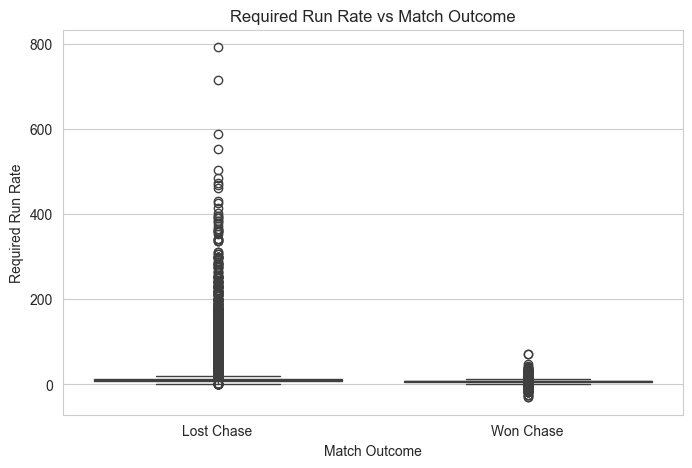


INSIGHT:
Higher required run rate generally increases pressure
Teams with very high RRR lose more often


In [ ]:
# VISUALIZATION & ANALYSIS

import matplotlib.pyplot as plt
import seaborn as sns

# Better plot style
sns.set_style("whitegrid")

# 1. REQUIRED RUN RATE vs MATCH OUTCOME

plt.figure(figsize=(8,5))

sns.boxplot(
    x='win',
    y='required_run_rate',
    data=df
)

plt.title("Required Run Rate vs Match Outcome")

plt.xlabel("Match Outcome")
plt.ylabel("Required Run Rate")

plt.xticks(
    [0,1],
    ['Lost Chase','Won Chase']
)

plt.show()


print("\nINSIGHT:")
print("Higher required run rate generally increases pressure")
print("Teams with very high RRR lose more often")


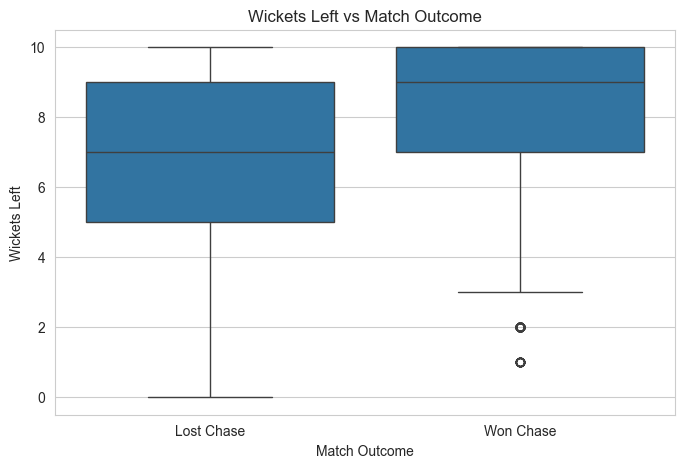


INSIGHT:
Teams with more wickets remaining have better chasing success
Wickets help teams handle pressure situations


In [ ]:
# 2. WICKETS LEFT vs MATCH OUTCOME

plt.figure(figsize=(8,5))

sns.boxplot(
    x='win',
    y='wickets_left',
    data=df
)

plt.title("Wickets Left vs Match Outcome")

plt.xlabel("Match Outcome")
plt.ylabel("Wickets Left")

plt.xticks(
    [0,1],
    ['Lost Chase','Won Chase']
)

plt.show()

print("\nINSIGHT:")
print("Teams with more wickets remaining have better chasing success")
print("Wickets help teams handle pressure situations")


Average Pressure by Over:

over
0      8.358411
1      8.407560
2      8.443158
3      8.441851
4      8.428136
5      8.457473
6      8.542702
7      8.662447
8      8.809943
9      8.958619
10     9.145419
11     9.365310
12     9.587255
13     9.899308
14    10.434627
15    11.068539
16    11.925329
17    13.556010
18    18.974182
19    53.172842
Name: required_run_rate, dtype: float64


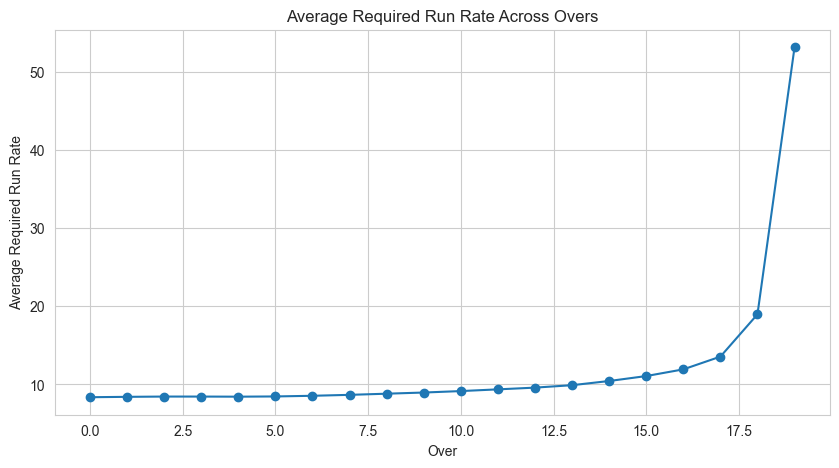


INSIGHT:
Pressure generally increases in later overs
Teams must score faster near the end of innings


In [47]:
# 3. PRESSURE TREND OVER OVERS

# Average required run rate at each over
over_pressure = df.groupby('over')['required_run_rate'].mean()

print("\nAverage Pressure by Over:\n")
print(over_pressure)


plt.figure(figsize=(10,5))

over_pressure.plot(
    marker='o'
)

plt.title("Average Required Run Rate Across Overs")

plt.xlabel("Over")
plt.ylabel("Average Required Run Rate")

plt.grid(True)

plt.show()


print("\nINSIGHT:")
print("Pressure generally increases in later overs")
print("Teams must score faster near the end of innings")

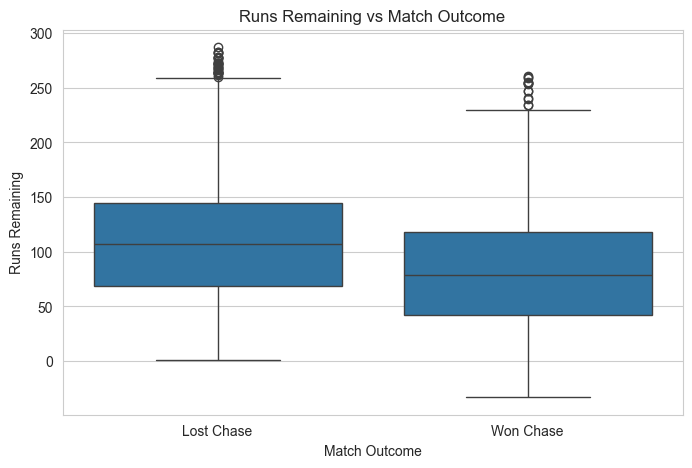


INSIGHT:
Teams needing too many runs later in innings struggle to win


In [48]:
# 4. RUNS REMAINING vs MATCH OUTCOME

plt.figure(figsize=(8,5))

sns.boxplot(
    x='win',
    y='runs_remaining',
    data=df
)

plt.title("Runs Remaining vs Match Outcome")

plt.xlabel("Match Outcome")
plt.ylabel("Runs Remaining")

plt.xticks(
    [0,1],
    ['Lost Chase','Won Chase']
)

plt.show()

print("\nINSIGHT:")
print("Teams needing too many runs later in innings struggle to win")



Correlation Matrix:

                   current_score  balls_left  wickets_left  runs_remaining  \
current_score           1.000000   -0.935412     -0.627692       -0.797957   
balls_left             -0.935412    1.000000      0.750769        0.820324   
wickets_left           -0.627692    0.750769      1.000000        0.477650   
runs_remaining         -0.797957    0.820324      0.477650        1.000000   
required_run_rate       0.210157   -0.258378     -0.383238       -0.029893   
win                     0.014463    0.054484      0.330129       -0.261210   

                   required_run_rate       win  
current_score               0.210157  0.014463  
balls_left                 -0.258378  0.054484  
wickets_left               -0.383238  0.330129  
runs_remaining             -0.029893 -0.261210  
required_run_rate           1.000000 -0.257140  
win                        -0.257140  1.000000  


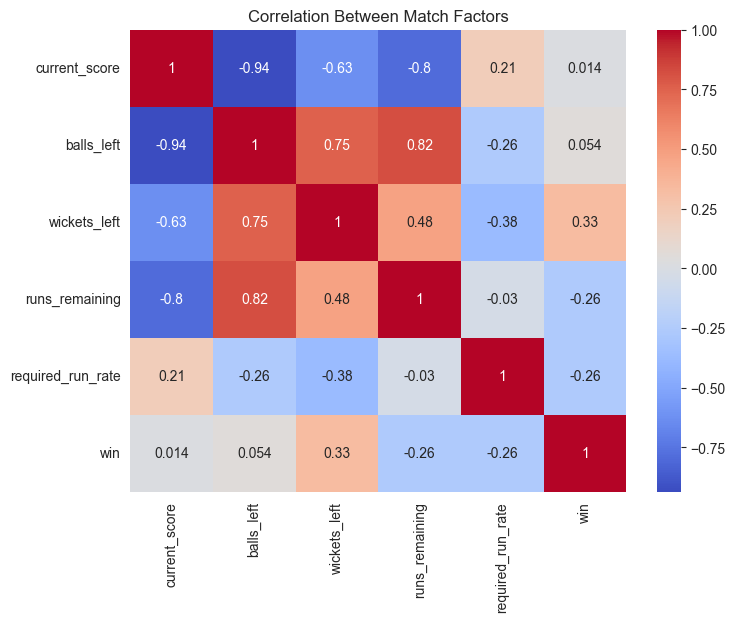


INSIGHT:
Required run rate negatively impacts winning chances
More wickets left positively influence winning chances


In [49]:
# 5. CORRELATION HEATMAP

plt.figure(figsize=(8,6))

corr = df[[
    'current_score',
    'balls_left',
    'wickets_left',
    'runs_remaining',
    'required_run_rate',
    'win'
]].corr()

print("\nCorrelation Matrix:\n")
print(corr)

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Between Match Factors")

plt.show()

print("\nINSIGHT:")
print("Required run rate negatively impacts winning chances")
print("More wickets left positively influence winning chances")


Win Percentage by RRR Category:

rrr_category
Low (0-6)            95.730506
Medium (6-8)         77.278532
High (8-10)          53.224786
Very High (10-12)    30.215308
Extreme (12+)        13.456938
Name: win, dtype: float64


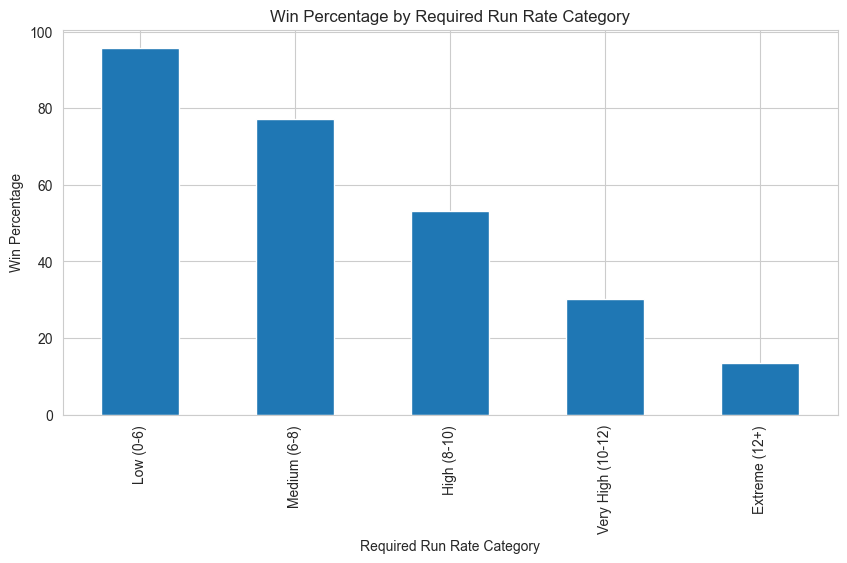


FINAL INSIGHT:
As required run rate increases, win percentage decreases
Extreme pressure situations are hardest to chase


In [50]:
# 6. WIN PERCENTAGE BY REQUIRED RUN RATE RANGE

# Create pressure categories
df['rrr_category'] = pd.cut(
    df['required_run_rate'],
    bins=[0,6,8,10,12,20],
    labels=[
        'Low (0-6)',
        'Medium (6-8)',
        'High (8-10)',
        'Very High (10-12)',
        'Extreme (12+)'
    ]
)

# Win percentage
rrr_win = df.groupby('rrr_category')['win'].mean() * 100

print("\nWin Percentage by RRR Category:\n")
print(rrr_win)


plt.figure(figsize=(10,5))

rrr_win.plot(
    kind='bar'
)

plt.title("Win Percentage by Required Run Rate Category")

plt.xlabel("Required Run Rate Category")
plt.ylabel("Win Percentage")

plt.show()


print("\nFINAL INSIGHT:")
print("As required run rate increases, win percentage decreases")
print("Extreme pressure situations are hardest to chase")

In [52]:
df.to_csv("chasing_analysis.csv", index=False)

# with pd.ExcelWriter("output/ipl_analysis.xlsx") as writer:
#     df.to_excel(writer, sheet_name="Chasing Analysis", index=False)c